<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка данных</a></span><ul class="toc-item"><li><span><a href="#Ресемплирование" data-toc-modified-id="Ресемплирование-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Ресемплирование</a></span></li></ul></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span><ul class="toc-item"><li><span><a href="#Тренды-и-сезонность" data-toc-modified-id="Тренды-и-сезонность-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Тренды и сезонность</a></span><ul class="toc-item"><li><span><a href="#Общая-статистика" data-toc-modified-id="Общая-статистика-2.1.1"><span class="toc-item-num">2.1.1&nbsp;&nbsp;</span>Общая статистика</a></span></li><li><span><a href="#Месячная-сезонность" data-toc-modified-id="Месячная-сезонность-2.1.2"><span class="toc-item-num">2.1.2&nbsp;&nbsp;</span>Месячная сезонность</a></span></li><li><span><a href="#Недельная-сезонность" data-toc-modified-id="Недельная-сезонность-2.1.3"><span class="toc-item-num">2.1.3&nbsp;&nbsp;</span>Недельная сезонность</a></span></li><li><span><a href="#Суточноя-сезонность" data-toc-modified-id="Суточноя-сезонность-2.1.4"><span class="toc-item-num">2.1.4&nbsp;&nbsp;</span>Суточноя сезонность</a></span></li></ul></li><li><span><a href="#Стационарность" data-toc-modified-id="Стационарность-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Стационарность</a></span><ul class="toc-item"><li><span><a href="#Вывод" data-toc-modified-id="Вывод-2.2.1"><span class="toc-item-num">2.2.1&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Добавление-признаков" data-toc-modified-id="Добавление-признаков-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Добавление признаков</a></span></li><li><span><a href="#Разделение-на-выборки-и-масштабирование" data-toc-modified-id="Разделение-на-выборки-и-масштабирование-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Разделение на выборки и масштабирование</a></span></li><li><span><a href="#Обучение-линейной-регрессии-(LinearRegression)" data-toc-modified-id="Обучение-линейной-регрессии-(LinearRegression)-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Обучение линейной регрессии (LinearRegression)</a></span></li><li><span><a href="#Обучение-дерева-решений-(DecisionTreeRegressor)" data-toc-modified-id="Обучение-дерева-решений-(DecisionTreeRegressor)-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Обучение дерева решений (DecisionTreeRegressor)</a></span></li><li><span><a href="#Обучение-knn-(KNeighborsRegressor)" data-toc-modified-id="Обучение-knn-(KNeighborsRegressor)-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Обучение knn (KNeighborsRegressor)</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-3.6"><span class="toc-item-num">3.6&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span><ul class="toc-item"><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Построим модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders`.

In [1696]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from sklearn.metrics import mean_squared_error

try:
    import phik
except:
    !pip install phik -q
    import phik
    
import warnings
warnings.filterwarnings('ignore')

## Подготовка данных

In [1697]:
data = pd.read_csv('/datasets/taxi.csv')

In [1698]:
data.head()

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


In [1699]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


Приведём столбец `datetime` к типу данных datetime64

In [1700]:
data['datetime'] = pd.to_datetime(data['datetime'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    26496 non-null  datetime64[ns]
 1   num_orders  26496 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 414.1 KB


Установим столбец `datetime` как индекс

In [1701]:
data.set_index('datetime', inplace=True)
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


Проверим в хронологическом ли порядке распологаются индексы

In [1702]:
if data.index.is_monotonic:
    print('Данные в хронологическом порядке')
else:
    print('Данные не в хронологическом порядке')

Данные в хронологическом порядке


### Ресемплирование

<AxesSubplot:xlabel='datetime'>

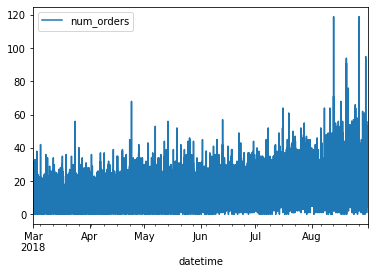

In [1703]:
data.plot()

Ресемплируем значения по 1 часу, считая среднее

<AxesSubplot:xlabel='datetime'>

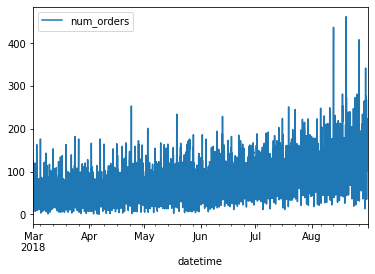

In [1704]:
data = data.resample('1H').sum()
data.plot()

## Анализ

### Тренды и сезонность

Выделим тренды и сезонность

In [1705]:
def decomp_plots(resample_value, data_t, only_seasonal=False):
    decomp = seasonal_decompose(data_t.resample(resample_value).sum())
    if(not only_seasonal):
        plt.figure(figsize=(6,8))

        plt.subplot(311)
        decomp.trend.plot(ax=plt.gca())
        plt.title('Trend')

        plt.subplot(312)
        decomp.seasonal.plot(ax=plt.gca())
        plt.title('Seasonal')

        plt.subplot(313)
        decomp.resid.plot(ax=plt.gca())
        plt.title('Residuals')

        plt.tight_layout()
    else:
        decomp.seasonal.plot(figsize=(12,3))

#### Общая статистика

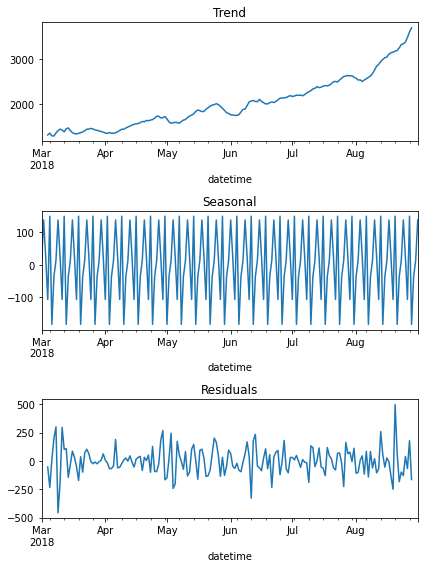

In [1706]:
decomp_plots('1D', data)

Виден тренд на увеличение кол-ва поездок, возможно это связано с тем, что летом чаще заказывают такси, но данные только за полгода, точно сказать нельзя, причём с августа идёт ускорение (квадратичный тренд)

Остатков в конце графика немного больше, что может приводить к отличиям оценки при обучении и на тестовой выборке

#### Месячная сезонность

In [1707]:
print([1,2,3][0])

1


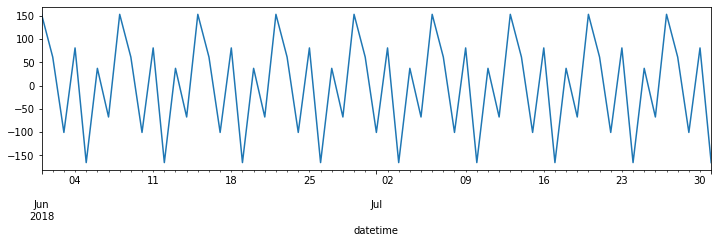

In [1708]:
decomp_plots('1D', data['2018-06-01':'2018-07-31'], only_seasonal=True)

Месячной сезонности не наблюдается

#### Недельная сезонность

Выведем данные за вторую и третью недели июня (с 4-го по 10-ое и с 11-го по 17-ое соответственно)

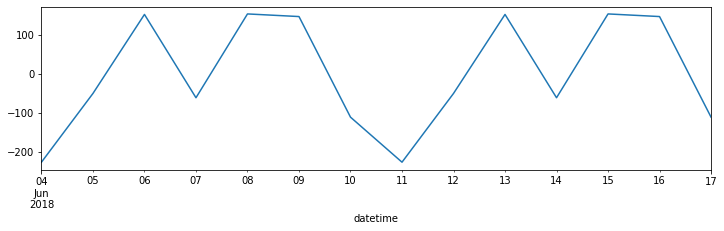

In [1709]:
decomp_plots('1D', data['2018-06-04':'2018-06-17'], only_seasonal=True)

Сезонность подствердилась

Видна недельная сезонность, имеем абсолютный минимум в понедельник, локальный минимум в четверг, максимум поездок в среду, пятницу и субботу.

#### Суточноя сезонность

Выведем почасовые значения в пятницу и субботу

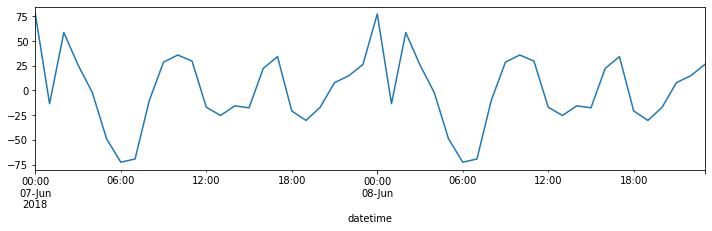

In [1710]:
decomp_plots('1H', data['2018-06-07':'2018-06-08'], only_seasonal=True)

Видна суточноя сезонность, минимум значений в 06:00, максимум в полночь, также есть пики в 10:00 и 17:00, что может быть связано с тем, что люди едут на работу и с работы.

### Стационарность

Выведем скользящее среденее и скользящее стандартное отклонение для определения стационарности

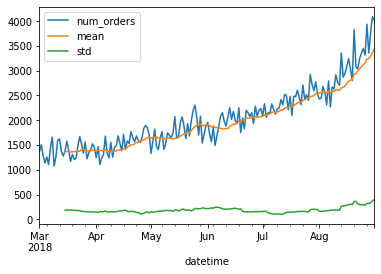

In [1711]:
data_t = data.copy()
data_t = data_t.resample('1D').sum()
data_t['mean'] = data_t['num_orders'].rolling(15).mean()
data_t['std'] = data_t['num_orders'].rolling(15).std()
data_t.plot()
del data_t

Среднее меняется, следовательно ряд нестационарный

#### Вывод

Виден тренд на увеличение кол-ва поездок, возможно это связано с тем, что летом чаще заказывают такси, но данные только за полгода, точно сказать нельзя, причём с августа идёт ускорение (квадратичный тренд)

Остатков в конце графика немного больше, что может приводить к отличиям оценки при обучении и на тестовой выборке

Видна недельная сезонность, имеем абсолютный минимум в понедельник, локальный минимум в четверг, максимум поездок в среду, пятницу и субботу.

Видна суточноя сезонность, минимум значений в 06:00, максимум в полночь, также есть пики в 10:00 и 17:00, что может быть связано с тем, что люди едут на работу и с работы.

Среднее меняется, следовательно ряд нестационарный

## Обучение

### Добавление признаков

In [1712]:
MAX_LAG = 12
ROLLING_MEAN_SIZE = 48
RANDOM_STATE = 72

Добавим календарные признаки, отстающие значения и скользящее среднее

In [1713]:
#data['month'] = data.index.month
data['day'] = data.index.day
data['dayofweek'] = data.index.dayofweek
data['hour'] = data.index.hour
for lag in range(1, MAX_LAG + 1):
    data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)
data['rolling_mean'] = data['num_orders'].shift().rolling(ROLLING_MEAN_SIZE).mean()

### Разделение на выборки и масштабирование

In [1714]:
train, test = train_test_split(data, shuffle=False, test_size=0.1)
train = train.dropna()

X_train = train.drop(['num_orders'], axis=1)
y_train = train['num_orders']

X_test = test.drop(['num_orders'], axis=1)
y_test = test['num_orders']

Масштабируем количественные признаки с помощью MinMaxScaler

In [1715]:
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [1716]:
del X_train, X_test, data

### Обучение линейной регрессии (LinearRegression)

In [1717]:
params_lr = {
    'fit_intercept' : [True, False]
}

randomized_search_lr = RandomizedSearchCV(
    LinearRegression(),
    param_distributions = params_lr,
    n_jobs = -1,
    cv = TimeSeriesSplit(),
    scoring = 'neg_root_mean_squared_error',
    random_state = RANDOM_STATE
)

randomized_search_lr.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=LinearRegression(), n_jobs=-1,
                   param_distributions={'fit_intercept': [True, False]},
                   random_state=72, scoring='neg_root_mean_squared_error')

In [1718]:
print(f'RMSE test: {-randomized_search_lr.cv_results_["mean_test_score"][randomized_search_lr.best_index_]}')

RMSE test: 31.599879710730043


### Обучение дерева решений (DecisionTreeRegressor)

In [1719]:
tree_params = {
    'max_depth' : range(1, 100),
    'min_samples_leaf' : range(1, 100),
    'min_samples_split' : range(2, 100)
}

randomized_search_tree = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions = tree_params,
    cv = TimeSeriesSplit(),
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE
)

randomized_search_tree.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=DecisionTreeRegressor(random_state=72), n_jobs=-1,
                   param_distributions={'max_depth': range(1, 100),
                                        'min_samples_leaf': range(1, 100),
                                        'min_samples_split': range(2, 100)},
                   random_state=72, scoring='neg_root_mean_squared_error')

In [1720]:
print(f'RMSE test: {-randomized_search_tree.cv_results_["mean_test_score"][randomized_search_tree.best_index_]}')

RMSE test: 27.897879527089053


### Обучение knn (KNeighborsRegressor)

In [1724]:
params_knn = {
    'n_neighbors' : range(1, 10),
    'leaf_size' : range(1, 10)
}

randomized_search_knn = RandomizedSearchCV(
    KNeighborsRegressor(),
    param_distributions = params_knn,
    cv = TimeSeriesSplit(),
    n_jobs=-1,
    n_iter = 20,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE
)

randomized_search_knn.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=KNeighborsRegressor(), n_iter=20, n_jobs=-1,
                   param_distributions={'leaf_size': range(1, 10),
                                        'n_neighbors': range(1, 10)},
                   random_state=72, scoring='neg_root_mean_squared_error')

In [1725]:
print(f'RMSE test: {-randomized_search_knn.cv_results_["mean_test_score"][randomized_search_knn.best_index_]}')

RMSE test: 28.501892636360083


### Вывод

Имеем следующие значения RMSE:

- Линейная регрессия (LinearRegression): 31.6
- Дерево решений (DecisionTreeRegressor): 27.9
- kNN (KNeighborsRegressor): 28.5

Лучшая модель - дерево решений

## Тестирование

Посчитаем метрику RMSE на X_test_scaled

In [1728]:
print(f'RMSE дерева решений: {mean_squared_error(y_test, randomized_search_tree.predict(X_test_scaled), squared=False)}')

RMSE дерева решений: 47.24119287124616


Построим график тестовых и предсказанных значений

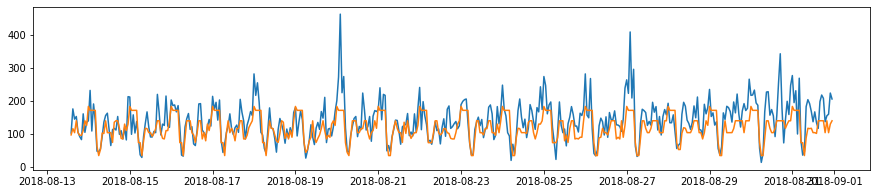

In [1737]:
plt.figure(figsize=(15, 3))
plt.plot(y_test)
plt.plot(pd.Series(randomized_search_tree.predict(X_test_scaled), index=y_test.index))

По графику видно, что модель плохо предсказывает сильные всплески спроса

### Вывод

По полученным данным была проведена следующая работа

**Подготовка данных**

- Столбец `datetime` приведён к типу datetime и установлен как индекс
- Данные ресемплированы по одному часу

**Анализ**

- Виден тренд на увеличение кол-ва поездок, возможно это связано с тем, что летом чаще заказывают такси, но данные только за полгода, точно сказать нельзя, причём с августа идёт ускорение (квадратичный тренд)

- Остатков в конце графика немного больше, что может приводить к отличиям оценки при обучении и на тестовой выборке

- Видна недельная сезонность, имеем абсолютный минимум в понедельник, локальный минимум в четверг, максимум поездок в среду, пятницу и субботу.

- Видна суточноя сезонность, минимум значений в 06:00, максимум в полночь, также есть пики в 10:00 и 17:00, что может быть связано с тем, что люди едут на работу и с работы.

- Среднее меняется, следовательно ряд нестационарный

**Обучения**

- В данные добавлены календарные признаки, отстающие признаки и скользящее среднее
- Обучены 3 модели, получены следующие метрики:
    - Линейная регрессия (LinearRegression): 31.6
    - Дерево решений (DecisionTreeRegressor): 27.9
    - kNN (KNeighborsRegressor): 28.5

Лучшая модель - дерево решений

**Тестирование**

Метрика RMSE лучшей модели на тестовой выборке: 47.24

По графику тестовой целевой метрики и предсказанной видно, что модель не очень хорошо предсказывает сильные всплески спроса.